## Access Animal Satellite Relay Tagging Diagnostic Realtime QC (Parquet)
This Jupyter notebook demonstrates how to access and plot animal_diag_satellite_relay_tagging_location_qc_realtime_qc data, available as a [Parquet](https://parquet.apache.org) dataset stored on S3.

🔗 More information about the dataset is available [in the AODN metadata catalogue](https://catalogue-imos.aodn.org.au/geonetwork/srv/eng/catalog.search#/metadata/b2548767-514f-4a31-b65e-36bb894382d5).

📌 The source of truth for this notebook is maintained on [GitHub](https://github.com/aodn/aodn_cloud_optimised/tree/main/notebooks/animal_diag_satellite_relay_tagging_location_qc_realtime_qc.ipynb).


In [1]:
dataset_name = "animal_diag_satellite_relay_tagging_location_qc_realtime_qc"

## Install/Update packages and Load common functions

In [2]:
import os, requests, importlib.util

open('setup.py', 'w').write(requests.get('https://raw.githubusercontent.com/aodn/aodn_cloud_optimised/main/notebooks/setup.py').text)

spec = importlib.util.spec_from_file_location("setup", "setup.py")
setup = importlib.util.module_from_spec(spec)
spec.loader.exec_module(setup)

setup.install_requirements()
setup.load_dataquery()

✅ Virtual environment already exists, skipping creation.


Using Python 3.12.11 environment at: /home/ecougnon/anaconda3/envs/AodnCloudOptimised
Resolved 201 packages in 76ms
Audited 201 packages in 0.09ms


✅ Local version 0.3.25 is up to date (remote: 0.3.25)


In [3]:
from DataQuery import GetAodn

/home/lbesnard/github_repo/aodn_cloud_optimised/notebooks/DataQuery.py:4676: UserWarning: registration of accessor <class 'DataQuery.AODNAccessor'> under name 'aodn' for type <class 'pandas.core.frame.DataFrame'> is overriding a preexisting attribute with the same name.
  @pd.api.extensions.register_dataframe_accessor("aodn")


# Understanding the Dataset

## Understanding Parquet Partitioning

Parquet files can be **partitioned** by one or more columns, which means the data is physically organised into folders based on the values in those columns. This is similar to how databases use indexes to optimise query performance.

Partitioning enables **faster filtering**: when you query data using a partitioned column, only the relevant subset of files needs to be read—improving performance significantly.

For example, if a dataset is partitioned by `"site_code"`, `"timestamp"`, and `"polygon"`, filtering on `"site_code"` allows the system to skip unrelated files entirely.

In this notebook, the `GetAodn` class includes built-in methods to efficiently filter data by **time** and **latitude/longitude** using the **timestamp** and **polygon** partitions. Other partitions can be used for filtering via the `scalar_filter`.

Any filtering on columns that are **not** partitioned can be significantly slower, as all files may need to be scanned. However, the `GetAodn` class provides a `scalar_filter` method that lets you apply these filters at load time—before the data is fully read—helping reduce the size of the resulting DataFrame.

Once the dataset is loaded, further filtering using Pandas is efficient and flexible.

See further below in the notebook for examples of how to filter the data effectively.

To view the actual partition columns for this dataset, run:


In [4]:
aodn = GetAodn()
dname = f'{dataset_name}.parquet'
%time aodn_dataset = aodn.get_dataset(dname)

CPU times: user 5.96 ms, sys: 992 µs, total: 6.96 ms
Wall time: 14.2 ms


In [5]:
aodn_dataset.dataset.partitioning.schema

timestamp: int32
polygon: string

## List unique partition values

In [7]:
%%time
unique_partition_value = aodn_dataset.get_unique_partition_values('YOUR_PARTITION_KEY')
print(list(unique_partition_value)[0:2])  # showing a subset only

[]
CPU times: user 55 µs, sys: 12 µs, total: 67 µs
Wall time: 70.6 µs


## Visualise Spatial Extent of the dataset
This section plots the polygons representing the areas where data is available. It helps to identify and create a bounding box around the regions containing data.

/home/ecougnon/anaconda3/envs/AodnCloudOptimised/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


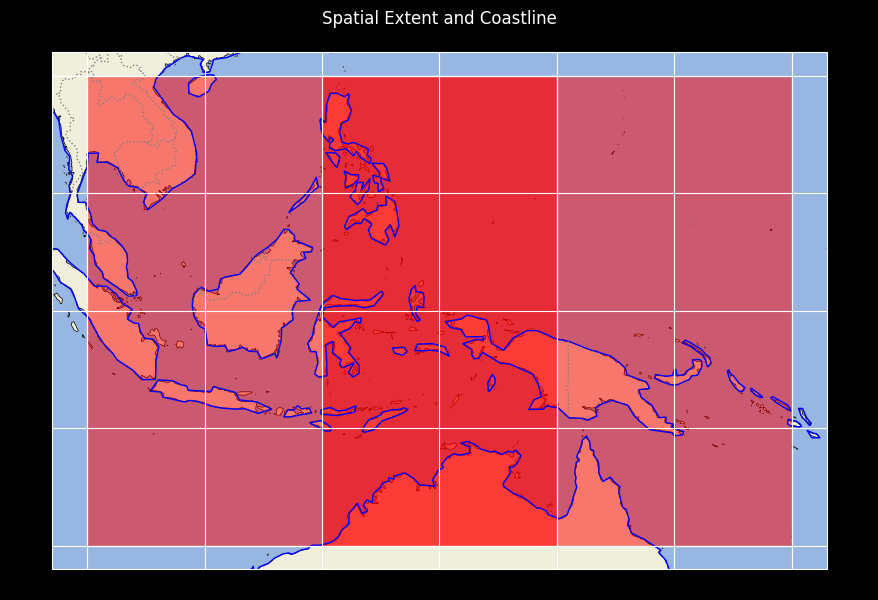

In [8]:
aodn_dataset.plot_spatial_extent()

## Get Temporal Extent of the dataset

Similary to the spatial extent, we're retrieving the minimum and maximum timestamp partition values of the dataset. This is not necessarely accurately representative of the TIME values, as the timestamp partition can be yearly/monthly... but is here to give an idea

In [9]:
%%time
aodn_dataset.get_temporal_extent()

CPU times: user 19.8 ms, sys: 3.96 ms, total: 23.8 ms
Wall time: 216 ms


(Timestamp('2026-05-19 07:55:54'), Timestamp('2026-07-14 10:54:55'))

## Read Metadata

For all Parquet datasets, we create a sidecar file named **_common_metadata** in the root of the dataset. This file contains both the dataset-level and variable-level attributes.  
The metadata can be retrieved below as a dictionary, and it will also be included in the pandas DataFrame when using the `get_data` method from the `GetAodn` class.

In [10]:
metadata = aodn_dataset.get_metadata()
metadata

2026-07-27 15:18:38,725 - aodn.GetAodn - INFO - Retrieving metadata for imos-optimised-nonproduction/animal_diag_satellite_relay_tagging_location_qc_realtime_qc.parquet


{'iq': {'type': 'int32',
  'comment': 'A two-digit code which gives further information about the location calculation for poor quality locations (see Argos documentation for a complete explanation)'},
 'lq': {'type': 'int32',
  'comment': 'The Location Quality assigned by Argos (-1 = class A, -2 = class B, -9 = class Z)'},
 'alt': {'type': 'double',
  'comment': '= 1 if the LAT,LON and ALT_LAT, ALT_LON were swapped by the location filter’s initial plausibility check'},
 'cid': {'type': 'string', 'comment': 'SMRU campaign name '},
 'lat': {'type': 'double',
  'units': 'degrees_north',
  'comment': 'Position estimate (WGS 84 datum)',
  'long_name': 'Latitude'},
 'lon': {'type': 'double',
  'units': 'degrees_east',
  'comment': 'Position estimate (WGS 84 datum)',
  'long_name': 'Longitude'},
 'ptt': {'type': 'int32',
  'comment': 'Argos PTT number is used',
  'long_name': 'Platform Transmitter Terminal'},
 'ref': {'type': 'string',
  'comment': 'A three-part code (e.g. rs3-Fred-07) : The

# Data Query and Plot

## Create a TIME and BoundingBox filter

This cell loads a subset of the dataset based on a time range and a spatial bounding box. The result is returned as a pandas DataFrame, and basic information about its structure is displayed.

In [11]:
%%time
# NRT dataset, so we re just showing how to do a time filtering here taking the whole data
df = aodn_dataset.get_data(date_start=aodn_dataset.get_temporal_extent()[0].strftime('%Y-%m-%d'), 
                           date_end=aodn_dataset.get_temporal_extent()[1].strftime('%Y-%m-%d'),
                           )

df.info()

2026-07-27 15:18:44,213 - aodn.GetAodn - INFO - Retrieving metadata for imos-optimised-nonproduction/animal_diag_satellite_relay_tagging_location_qc_realtime_qc.parquet


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14271 entries, 0 to 14270
Data columns (total 38 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   iq                   14271 non-null  int32         
 1   lq                   14271 non-null  int32         
 2   alt                  0 non-null      float64       
 3   cid                  14271 non-null  object        
 4   lat                  14271 non-null  float64       
 5   lon                  14271 non-null  float64       
 6   ptt                  14271 non-null  int32         
 7   ref                  14271 non-null  object        
 8   freq                 14271 non-null  float64       
 9   hdop                 0 non-null      float64       
 10  nops                 14271 non-null  int32         
 11  ssm_x                13186 non-null  float64       
 12  ssm_y                13186 non-null  float64       
 13  d_date               14271 non-

In [12]:
df

,iq,lq,alt,cid,lat,lon,ptt,ref,freq,hdop,...,actual_ptt,best_level,n_mess_120,error_radius,km_from_home,semi_major_axis,semi_minor_axis,ellipse_orientation,timestamp,polygon
0,99,-1,NaN,tu126,-11.70305,135.16834,285688,tu126-Star-25,4.016775e+08,NaN,...,285688,0,0,580,0.581,580,580,0,1767225600,0103000000010000000500000000000000000059400000...
1,99,-2,NaN,tu126,-11.69554,135.16894,285676,tu126-Ella-25,4.016776e+08,NaN,...,285676,0,0,596,0.733,596,596,0,1767225600,0103000000010000000500000000000000000059400000...
2,99,-1,NaN,tu126,-11.69883,135.17044,285685,tu126-Tito-25,4.016776e+08,NaN,...,285685,0,0,388,0.713,388,388,0,1767225600,0103000000010000000500000000000000000059400000...
3,99,-2,NaN,tu126,-11.70144,135.16668,285688,tu126-Star-25,4.016775e+08,NaN,...,285688,0,0,454,0.333,454,454,0,1767225600,0103000000010000000500000000000000000059400000...
4,99,-2,NaN,tu126,-11.69789,135.16935,285676,tu126-Ella-25,4.016776e+08,NaN,...,285676,0,0,399,0.629,399,399,0,1767225600,0103000000010000000500000000000000000059400000...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14266,99,2,NaN,tu126,-11.90251,137.95303,41845,tu126-Rapunzel-26,4.016775e+08,NaN,...,41845,0,0,268,304.737,268,268,0,1767225600,0103000000010000000500000000000000000059400000...
14267,99,3,NaN,tu126,-11.90238,137.95301,41845,tu126-Rapunzel-26,4.016775e+08,NaN,...,41845,0,0,238,304.733,238,238,0,1767225600,0103000000010000000500000000000000000059400000...
14268,99,-1,NaN,tu126,-11.23741,135.30931,285680,tu126-Raya-25,4.016775e+08,NaN,...,285680,0,0,860,53.879,860,860,0,1767225600,0103000000010000000500000000000000000059400000...
14269,99,-1,NaN,tu126,-14.17474,136.88852,39363,tu126-Andy-26,4.016776e+08,NaN,...,39363,0,0,698,332.998,698,698,0,1767225600,0103000000010000000500000000000000000059400000...


In [12]:
## Download Subsetted Data as CSV

# This cell downloads the filtered dataset as a ZIP-compressed CSV file.  
# The CSV includes metadata at the top as commented lines, and a `FileLink` object is returned to allow downloading directly from the notebook.


#df.aodn.download_as_csv()

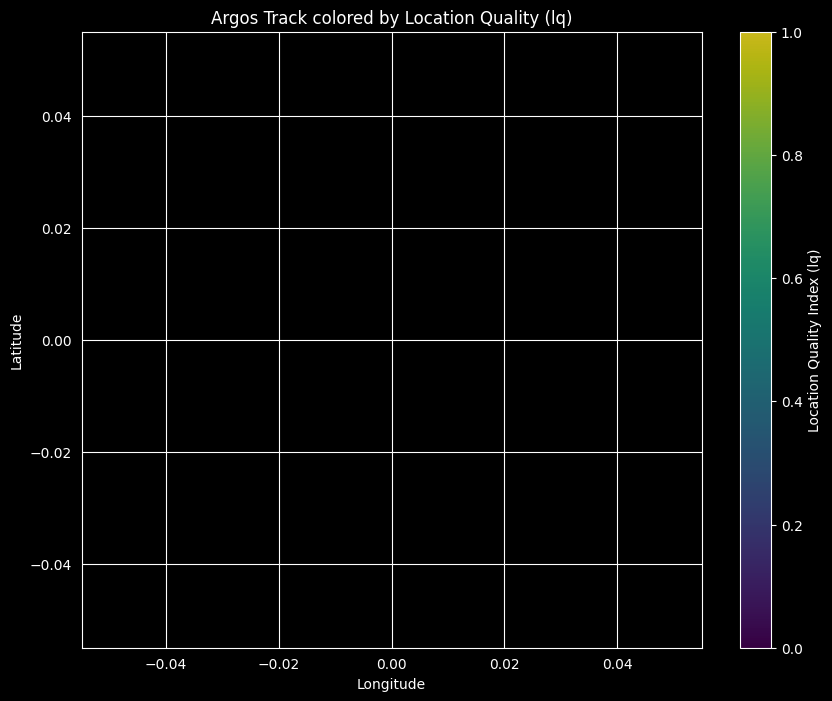

In [14]:
import matplotlib.pyplot as plt

# Filter for a single seal to see a clean track
seal_df = df[df["ptt"] == 265888].sort_values(by="d_date")

fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(
    seal_df["lon"],
    seal_df["lat"],
    c=seal_df["lq"],
    cmap="viridis",
    s=25,
    alpha=0.8,
)

# Connect the dots chronologically
ax.plot(seal_df["lon"], seal_df["lat"], color="gray", linestyle="-", alpha=0.5)

ax.set_title("Argos Track colored by Location Quality (lq)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Location Quality Index (lq)")
plt.show()

# Dynamic Argos Telemetry & Tracking of Seal PTT 265888

ValueError: Axis limits cannot be NaN or Inf

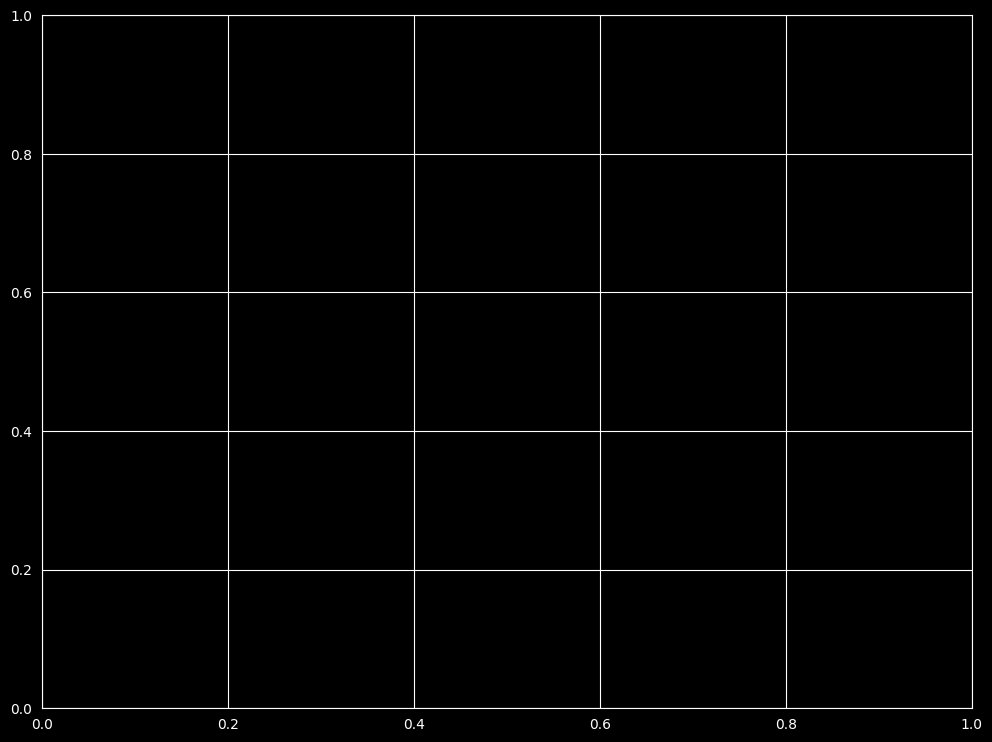

In [15]:
import matplotlib.animation as animation
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import pandas as pd
from IPython.display import HTML

# =========================================================================
# 1. PURE NUMERIC DATA PREPARATION
# =========================================================================
target_ptt = 265888
seal_df = df[df["ptt"] == target_ptt].sort_values(by="d_date").copy()

# Ensure datetimes are clean and remove rows without spatial coordinates
seal_df["d_date"] = pd.to_datetime(seal_df["d_date"])
seal_df = seal_df.dropna(subset=["d_date", "lon", "lat"])
seal_df["date_only"] = seal_df["d_date"].dt.date

unique_days = sorted(seal_df["date_only"].unique())
day_groups = seal_df.groupby("date_only")

# Pre-allocate dictionary histories for line tracks AND single-point ellipse metadata
track_history = {}
ellipse_history = {}
accumulated_lon = []
accumulated_lat = []

# Scaling factor to make meters-based error attributes visible on a degree grid
scale = 0.001 

for day in unique_days:
    if day in day_groups.groups:
        day_df = day_groups.get_group(day)
        accumulated_lon.extend(day_df["lon"].tolist())
        accumulated_lat.extend(day_df["lat"].tolist())
        
        # Grab the very last known telemetry point of the day to position the active ellipse
        last_row = day_df.iloc[-1]
        current_ellipse_data = {
            "visible": True,
            "xy": (last_row["lon"], last_row["lat"]),
            "width": last_row["semi_major_axis"] * scale,
            "height": last_row["semi_minor_axis"] * scale,
            "angle": last_row["ellipse_orientation"]
        }
    else:
        # If no new data on this day, keep previous position metadata
        current_ellipse_data = current_ellipse_data.copy() if 'current_ellipse_data' in locals() else {"visible": False}

    track_history[day] = (list(accumulated_lon), list(accumulated_lat))
    ellipse_history[day] = current_ellipse_data

# =========================================================================
# 2. VANILLA CANVAS SETUP
# =========================================================================
fig, ax = plt.subplots(figsize=(12, 9))

# Set fixed bounds manually based on your data coordinates
pad = 2.0
lon_min, lon_max = seal_df["lon"].min() - pad, seal_df["lon"].max() + pad
lat_min, lat_max = seal_df["lat"].min() - pad, seal_df["lat"].max() + pad

ax.set_xlim(lon_min, lon_max)
ax.set_ylim(lat_min, lat_max)
ax.grid(True, linestyle="--", alpha=0.5)
ax.set_facecolor("aliceblue")  # Light blue background to substitute ocean

# Initialize standard tracking line
(track_line,) = ax.plot([], [], linestyle="-", linewidth=2.0, color="royalblue", alpha=0.8)

# Initialize a single error ellipse placeholder patch
active_ellipse = Ellipse(
    xy=(0, 0), width=0, height=0, angle=0,
    edgecolor="crimson", facecolor="none", linewidth=2.0, alpha=0.8
)
ax.add_patch(active_ellipse)

title_text = ax.text(0.5, 1.02, "", transform=ax.transAxes, ha="center", va="bottom", fontsize=14)
plt.tight_layout()

# =========================================================================
# 3. FAST ANIMATION UPDATE LOOP
# =========================================================================
def update(frame):
    current_day = unique_days[frame]
    
    # Update line coordinates
    lons, lats = track_history[current_day]
    track_line.set_data(lons, lats)
    
    # Update ellipse properties dynamically
    e_data = ellipse_history[current_day]
    if e_data.get("visible", False):
        active_ellipse.set_visible(True)
        active_ellipse.set_center(e_data["xy"])
        active_ellipse.set_width(e_data["width"])
        active_ellipse.set_height(e_data["height"])
        active_ellipse.set_angle(e_data["angle"])
    else:
        active_ellipse.set_visible(False)

    title_text.set_text(
        f"Seal {target_ptt} Telemetry Tracking\nDate: {current_day.strftime('%Y-%m-%d')} | Crimson Ring = Current Error Boundary"
    )
    
    return [track_line, active_ellipse, title_text]

# Run animation with blit=True for near-instant rendering
ani = animation.FuncAnimation(
    fig, update, frames=len(unique_days), interval=100, blit=True
)
plt.close()

HTML(ani.to_jshtml())